# Exercise 2 — Neural Networks Used in an Unusual Way
## Neural Network as a Semantic Resonance Instrument

In this exercise the neural network is not presented as a typical classifier. It becomes a small resonance instrument: it receives symbolic vectors such as intensity, uncertainty and coherence, learns hidden patterns, and then maps a new signal into a latent emotional/strategic state. The implementation is pure NumPy, so it should run even without TensorFlow.

In [1]:

import numpy as np
import pandas as pd

np.random.seed(42)

# Three abstract dimensions:
# intensity, uncertainty, coherence
X = np.array([
    [0.95, 0.10, 0.90],  # high power / high coherence
    [0.15, 0.90, 0.20],  # diffuse / unstable
    [0.85, 0.25, 0.80],
    [0.20, 0.85, 0.15],
    [0.70, 0.40, 0.65],
    [0.35, 0.75, 0.30],
])

# 0 = resonant / coherent field
# 1 = unstable / noisy field
y = np.array([[0], [1], [0], [1], [0], [1]])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

input_dim = 3
hidden_dim = 5
output_dim = 1

W1 = np.random.randn(input_dim, hidden_dim) * 0.5
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.5
b2 = np.zeros((1, output_dim))

lr = 0.8
losses = []

for epoch in range(3000):
    # forward pass
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # backward pass
    d_loss = 2 * (y_hat - y) / len(y)
    d_z2 = d_loss * sigmoid_derivative(y_hat)
    d_W2 = a1.T @ d_z2
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)

    d_a1 = d_z2 @ W2.T
    d_z1 = d_a1 * sigmoid_derivative(a1)
    d_W1 = X.T @ d_z1
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)

    W2 -= lr * d_W2
    b2 -= lr * d_b2
    W1 -= lr * d_W1
    b1 -= lr * d_b1

print('Final loss:', round(losses[-1], 6))


Final loss: 0.000333


In [2]:

test_signals = np.array([
    [0.90, 0.15, 0.85],
    [0.25, 0.80, 0.20],
    [0.65, 0.50, 0.70],
    [0.50, 0.60, 0.40],
])

hidden = sigmoid(test_signals @ W1 + b1)
predictions = sigmoid(hidden @ W2 + b2)

result = pd.DataFrame(test_signals, columns=['intensity', 'uncertainty', 'coherence'])
result['instability_probability'] = predictions.ravel()
result['field_state'] = np.where(result['instability_probability'] < 0.5, 'RESONANT', 'UNSTABLE')

result


,intensity,uncertainty,coherence,instability_probability,field_state
0,0.90,0.15,0.85,0.002848,RESONANT
1,0.25,0.80,0.20,0.990973,UNSTABLE
2,0.65,0.50,0.70,0.064245,RESONANT
3,0.50,0.60,0.40,0.673486,UNSTABLE


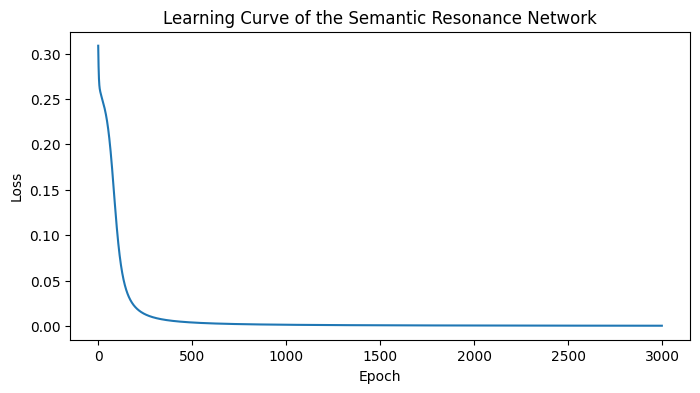

In [3]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title('Learning Curve of the Semantic Resonance Network')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


Discussion:
- The network is not merely classifying flowers or digits.
- It learns a tiny latent grammar of abstract states.
- This lets students see neural networks as instruments for mapping hidden fields of meaning, tension and instability.